In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("Setup successful ✅")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)


Setup successful ✅
NumPy: 1.26.4
Pandas: 2.2.2
OpenCV: 4.8.1
TensorFlow: 2.15.0


In [2]:
import os

os.listdir("data/gtsrb")

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']

In [3]:
import pandas as pd
import os

DATA_DIR = "data/gtsrb"

train_df = pd.read_csv(os.path.join(DATA_DIR, "Train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "Test.csv"))

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (39209, 8)
Test Shape: (12630, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
print("Number of classes:", train_df["ClassId"].nunique())

Number of classes: 43


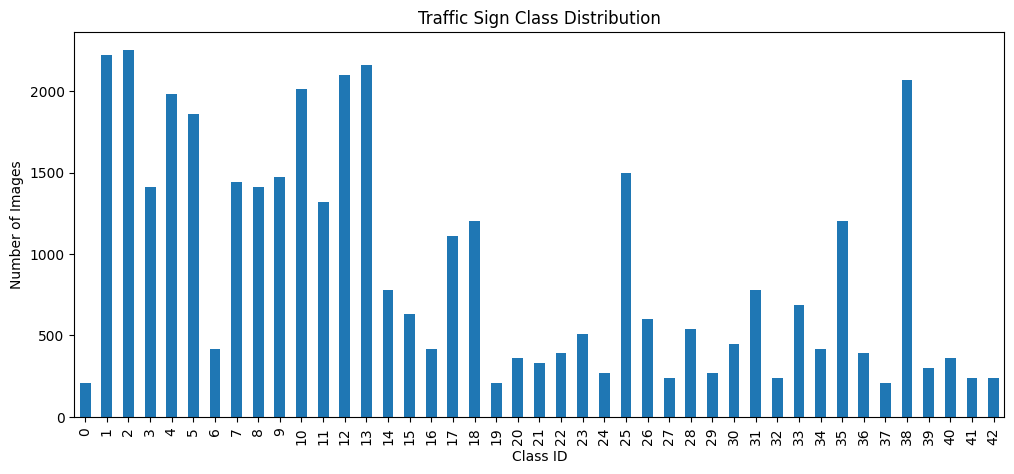

In [5]:
train_df["ClassId"].value_counts().sort_index().plot(kind="bar", figsize=(12,5))

plt.title("Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")

plt.show()

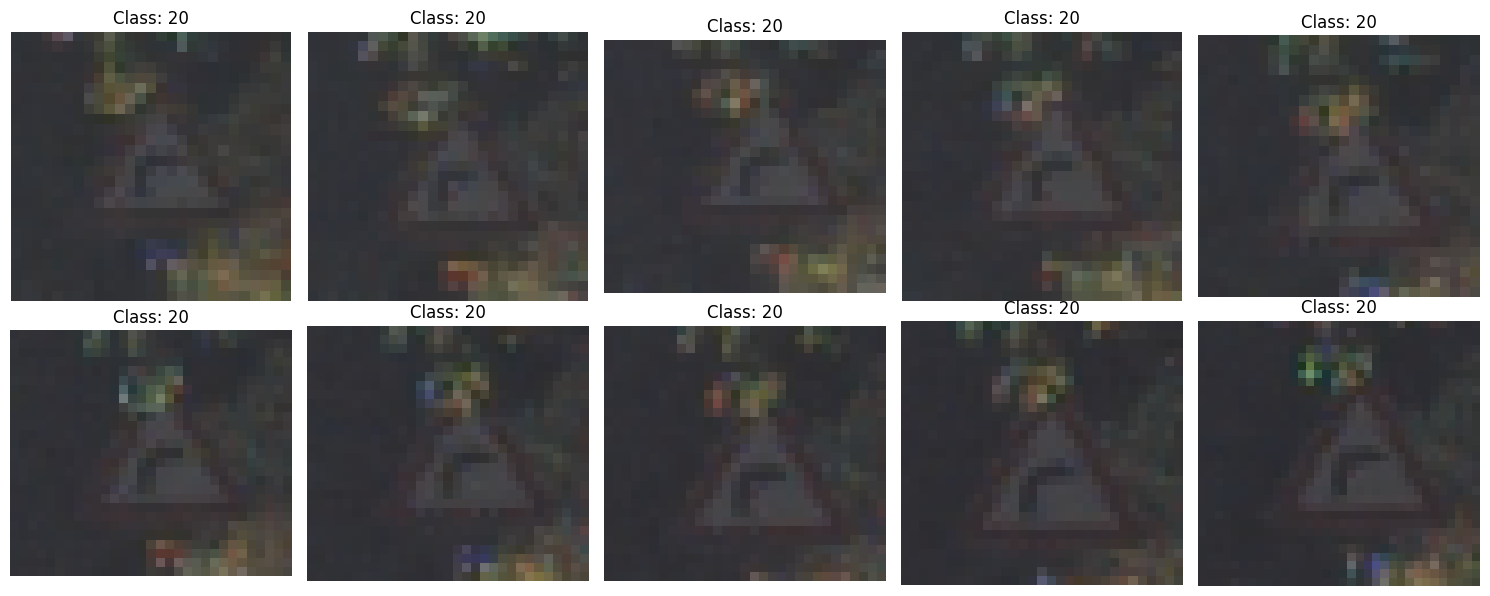

In [6]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):
    
    img_path = os.path.join(DATA_DIR, train_df.iloc[i]["Path"])
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    ax.imshow(img)
    ax.set_title(f'Class: {train_df.iloc[i]["ClassId"]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Preprocessing images

IMG_SIZE = 32

images = []
labels = []

for index, row in train_df.iterrows():
    
    img_path = os.path.join(DATA_DIR, row["Path"])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    images.append(img)
    labels.append(row["ClassId"])

#Converting to NumPy arrays
X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39209, 32, 32, 3)
y shape: (39209,)


In [9]:
#Splitting datasets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (31367, 32, 32, 3)
X_val: (7842, 32, 32, 3)
y_train: (31367,)
y_val: (7842,)


#Building the CNN model

We use a simple Convolutional Neural Network (CNN) for traffic sign image classification.

In [10]:
from tensorflow.keras import models, layers

num_classes = 43

model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation='relu'
    ),

    layers.Dense(
        num_classes,
        activation='softmax'
    )

])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 64)               

In [11]:
#Compile and train model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_val, y_val)
)


Epoch 1/5


981/981 [==============================] - 8s 7ms/step - loss: 1.2026 - accuracy: 0.6741 - val_loss: 0.3667 - val_accuracy: 0.8925
Epoch 2/5
981/981 [==============================] - 6s 6ms/step - loss: 0.2166 - accuracy: 0.9422 - val_loss: 0.1646 - val_accuracy: 0.9615
Epoch 3/5
981/981 [==============================] - 6s 6ms/step - loss: 0.1182 - accuracy: 0.9697 - val_loss: 0.1019 - val_accuracy: 0.9748
Epoch 4/5
981/981 [==============================] - 6s 6ms/step - loss: 0.0739 - accuracy: 0.9809 - val_loss: 0.1067 - val_accuracy: 0.9727
Epoch 5/5
981/981 [==============================] - 6s 6ms/step - loss: 0.0550 - accuracy: 0.9859 - val_loss: 0.0903 - val_accuracy: 0.9778


In [12]:
model.save("traffic_model.h5")

print("Model saved successfully ✅")

Model saved successfully ✅


c:\Users\khyle\Desktop\traffic-sign-classifier\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#Model performance visualization

We visualize training and validation accuracy/loss to evaluate learning behavior and detect possible overfitting.

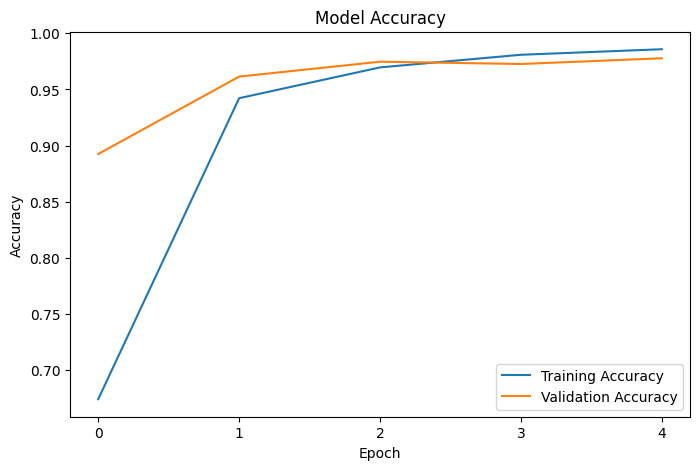

In [ ]:
#Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(range(5))

plt.legend()

plt.show()

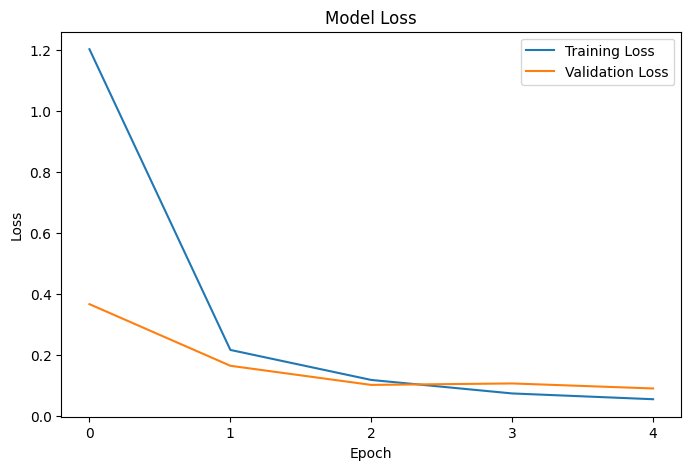

In [16]:
# Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(5))

plt.legend()

plt.show()

#Testing Predictions on Validation Images

The trained CNN is tested on unseen validation images to observe prediction performance.

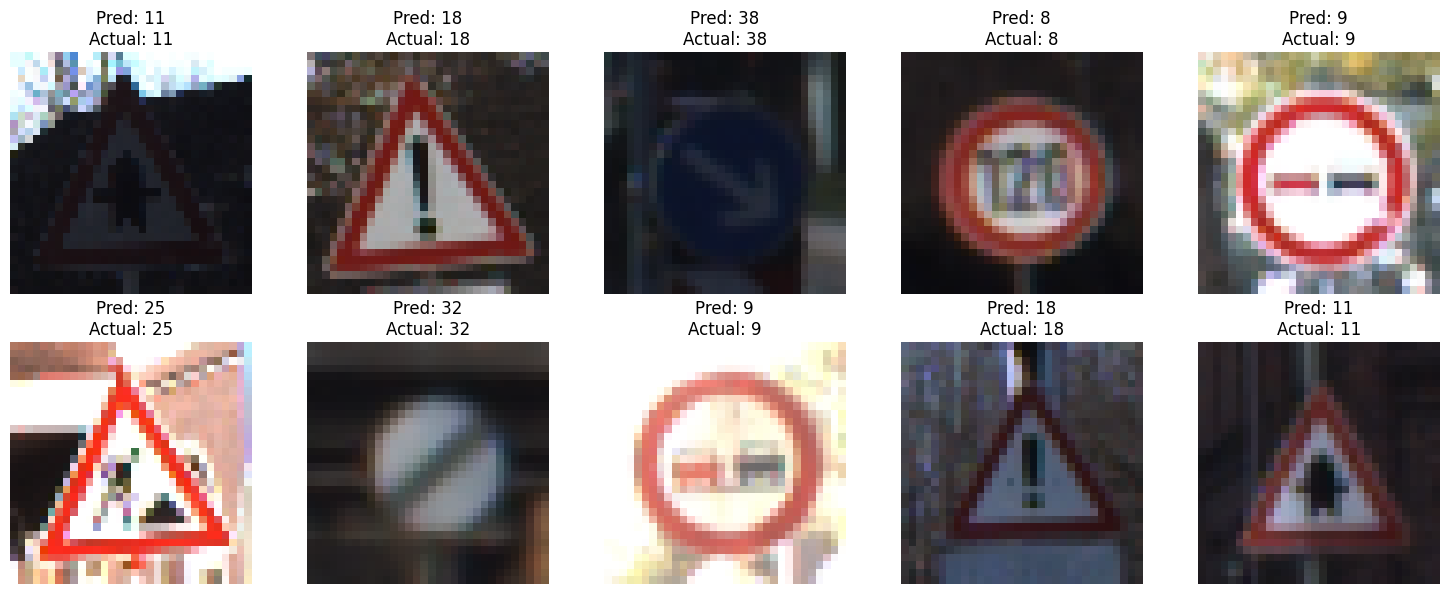

In [17]:
import random

class_names = [str(i) for i in range(43)]

indices = random.sample(range(len(X_val)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):

    idx = indices[i]

    img = X_val[idx]

    prediction = model.predict(np.expand_dims(img, axis=0), verbose=0)

    predicted_class = np.argmax(prediction)

    actual_class = y_val[idx]

    ax.imshow(img)

    ax.set_title(
        f'Pred: {predicted_class}\nActual: {actual_class}'
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

#Confusion Matrix

The confusion matrix visualizes prediction performance across all traffic sign classes.

246/246 [==============================] - 1s 2ms/step


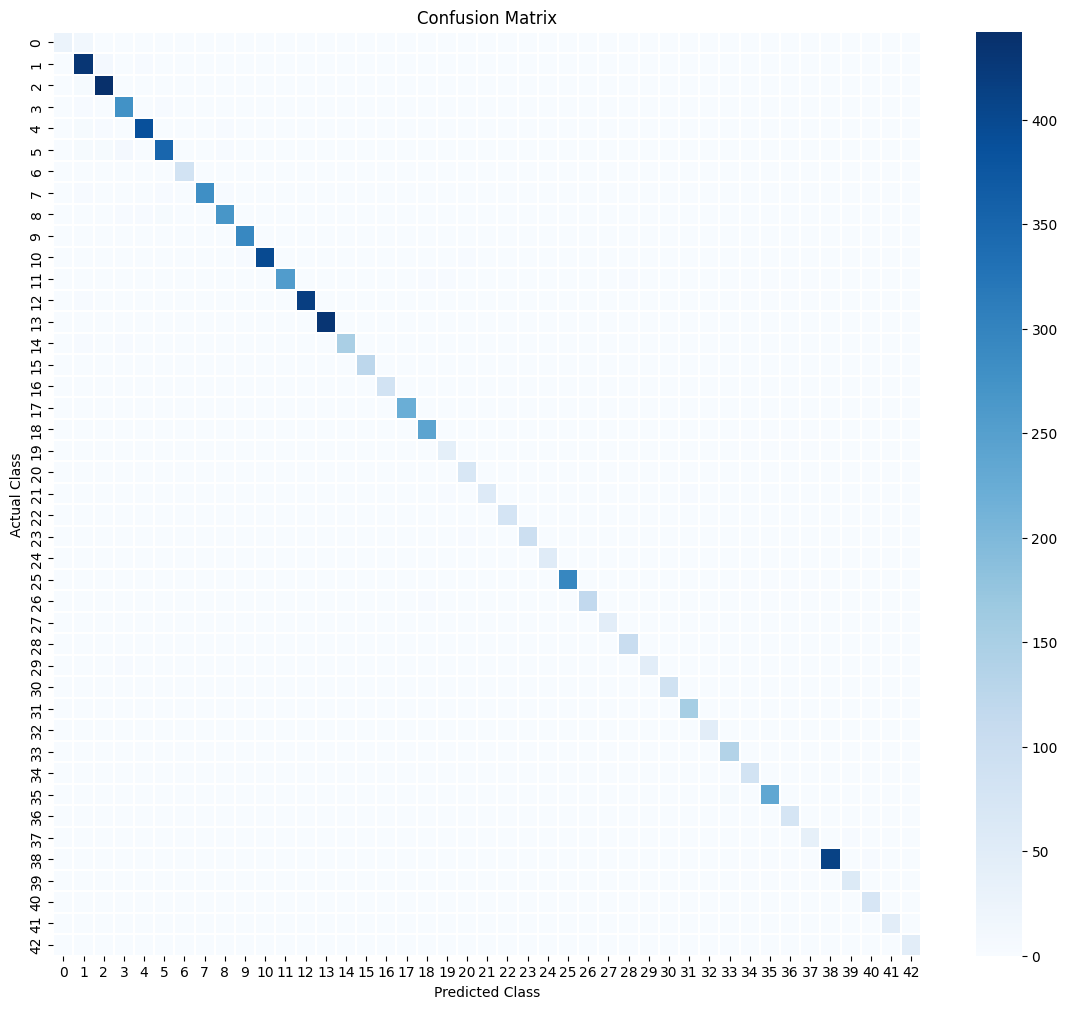

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_val)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap='Blues',
    linewidths=0.1
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()